# Uji Normalitas

In [12]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
tokped = pd.read_csv('tokopedia_clean.csv')
tokped

,nama produk,harga,jumlah,kategori
0,Denpoo Mesin Cuci 2 Tabung DW 9292 4P Kapasita...,1532000,750,Mesin Cuci
1,Arashi Laundry AWM 452A Mesin Cuci 1 Tabung 4....,1442800,500,Mesin Cuci
2,MESIN CUCI 1 TABUNG AQUA JAPAN AQW 77 DH / FW...,2450000,1000,Mesin Cuci
3,Mesin Cuci 1 Tabung AQUA QW 77 DH 7.5 KG Hijab...,2381000,250,Mesin Cuci
4,Sanken Mesin Cuci Twin Tub TW-882BP 9kg Mesin ...,2600000,750,Mesin Cuci
...,...,...,...,...
64,Google TV 50 Inch Hisense U6K 50 ULED TV Quant...,7490000,1,TV
65,LG Freezer GN-INV304BK ( Black ) / FREEZER LG ...,4199388,1,Kulkas
66,AQUA CHEST FREEZER AQF-500 W/ LEMARI PEMBEKU/ ...,7999000,4,Kulkas
67,SAMSUNG RT31CG5420B1SE / RT31 Kulkas 2 Pintu w...,6699000,50,Kulkas


In [15]:
stat, p_value = stats.shapiro(tokped['harga'])
print(f"Shapiro-Wilk Stat: {stat:.4f}, p-value: {p_value:.4f}")

Shapiro-Wilk Stat: 0.3994, p-value: 0.0000


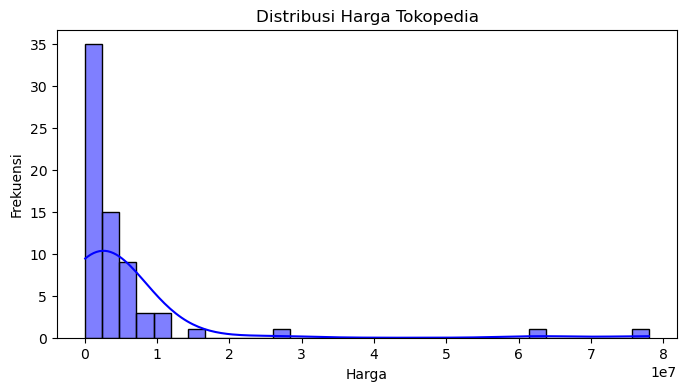

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 4))
sns.histplot(tokped['harga'], kde=True, color='blue')
plt.title('Distribusi Harga Tokopedia')
plt.xlabel('Harga')
plt.ylabel('Frekuensi')
plt.show()

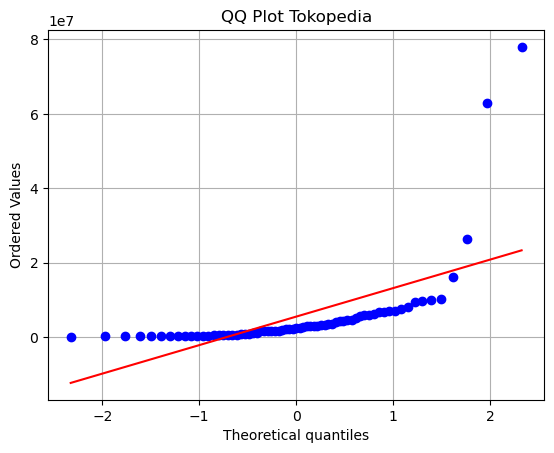

In [26]:
stats.probplot(tokped['harga'], dist="norm", plot=plt)
plt.title("QQ Plot Tokopedia")
plt.grid(True)
plt.show()

In [18]:
shopee = pd.read_csv('shopee_clean.csv')
shopee

,nama produk,harga,jumlah,kategori
0,Lampu Tumblr Kawat Mini 1-5M LED Diskon,2298,10000,Lampu
1,Gogolampu LED Hias Tumbler Bunga Balon,2281,10000,Lampu
2,Lampu LED 3 Mata 12V Roshan 6011,1470,10000,Lampu
3,Lampu LED Neon Flex 220V Waterproof 1M-100M,5800,10000,Lampu
4,GOGOLAND E005 Lampu Lilin elektrik LED,1879,10000,Lampu
5,ANG SARUNG JARI / SARUNG JEMPOL GAME,2600,10000,Sarung Jari
6,Lampu Hias LED 1M 10 LED Indoor Outdoor,2176,10000,Lampu
7,BG Lampu Tumblr Mini 1-5M LED 3 Mode,2274,10000,Lampu
8,"Kapasitor Kipas Angin CBB61 1.2UF, 1.5UF",2750,10000,Kapasitor Kipas Angin
9,Klem LED Strip Transparan / Klem Lampu,900,10000,Lampu


In [20]:
stat, p_value = stats.shapiro(shopee['harga'])
print(f"Shapiro-Wilk Stat: {stat:.4f}, p-value: {p_value:.4f}")

Shapiro-Wilk Stat: 0.4716, p-value: 0.0000


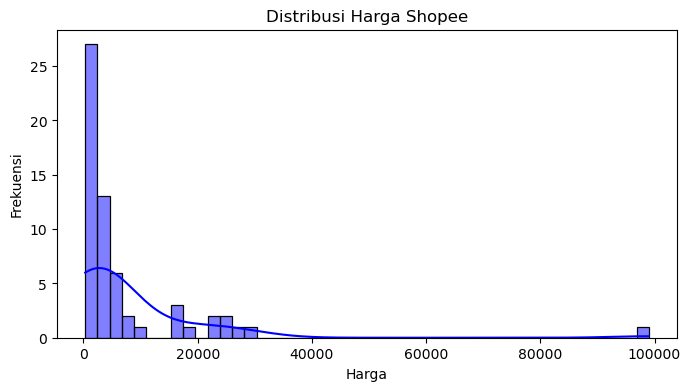

In [34]:
plt.figure(figsize=(8, 4))
sns.histplot(shopee['harga'], kde=True, color='blue')
plt.title('Distribusi Harga Shopee')
plt.xlabel('Harga')
plt.ylabel('Frekuensi')
plt.show()

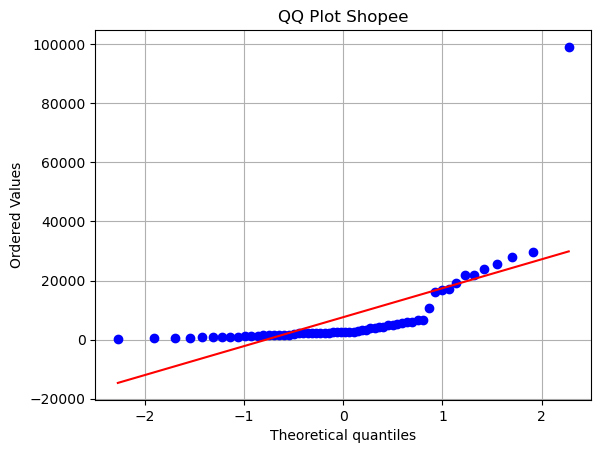

In [36]:
stats.probplot(shopee['harga'], dist="norm", plot=plt)
plt.title("QQ Plot Shopee")
plt.grid(True)
plt.show()

# Mann-Whitney U test

In [41]:
from scipy import stats

stat, p_value = stats.mannwhitneyu(tokped['harga'], shopee['harga'], alternative='two-sided')

n1 = len(tokped['harga'])
n2 = len(shopee['harga'])

# Effect Size
rank_biserial = 1 - (2 * stat) / (n1 * n2)
cles = stat / (n1 * n2)

print(f"Nilai U Statistic: {stat}")
print(f"Nilai P-Value    : {p_value:.5f}")
print(f"Rank-Biserial Correlation (r): {rank_biserial:.4f}")
print(f"Common Language Effect Size  : {cles:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Kesimpulan: Terdapat perbedaan yang signifikan antara kedua kelompok (Tolak H0).")
else:
    print("Kesimpulan: Tidak terdapat perbedaan yang signifikan antara kedua kelompok (Gagal Tolak H0).")

Nilai U Statistic: 4138.0
Nilai P-Value    : 0.00000
Rank-Biserial Correlation (r): -0.9990
Common Language Effect Size  : 0.9995
Kesimpulan: Terdapat perbedaan yang signifikan antara kedua kelompok (Tolak H0).


# Alasan Internal

In [146]:
tokped = pd.read_csv('tokopedia_clean.csv')
tokped

,nama produk,harga,jumlah,kategori
0,Denpoo Mesin Cuci 2 Tabung DW 9292 4P Kapasita...,1532000,750,Mesin Cuci
1,Arashi Laundry AWM 452A Mesin Cuci 1 Tabung 4....,1442800,500,Mesin Cuci
2,MESIN CUCI 1 TABUNG AQUA JAPAN AQW 77 DH / FW...,2450000,1000,Mesin Cuci
3,Mesin Cuci 1 Tabung AQUA QW 77 DH 7.5 KG Hijab...,2381000,250,Mesin Cuci
4,Sanken Mesin Cuci Twin Tub TW-882BP 9kg Mesin ...,2600000,750,Mesin Cuci
...,...,...,...,...
64,Google TV 50 Inch Hisense U6K 50 ULED TV Quant...,7490000,1,TV
65,LG Freezer GN-INV304BK ( Black ) / FREEZER LG ...,4199388,1,Kulkas
66,AQUA CHEST FREEZER AQF-500 W/ LEMARI PEMBEKU/ ...,7999000,4,Kulkas
67,SAMSUNG RT31CG5420B1SE / RT31 Kulkas 2 Pintu w...,6699000,50,Kulkas


In [148]:
jumlah

jumlah
750      8
250      7
100      5
2        4
3        4
2000     4
1000     4
3000     3
500      3
1        3
40       3
4        2
30       2
11       2
5        2
25       2
9        2
50       1
16       1
20       1
7        1
6        1
5000     1
10000    1
6000     1
60       1
Name: count, dtype: int64

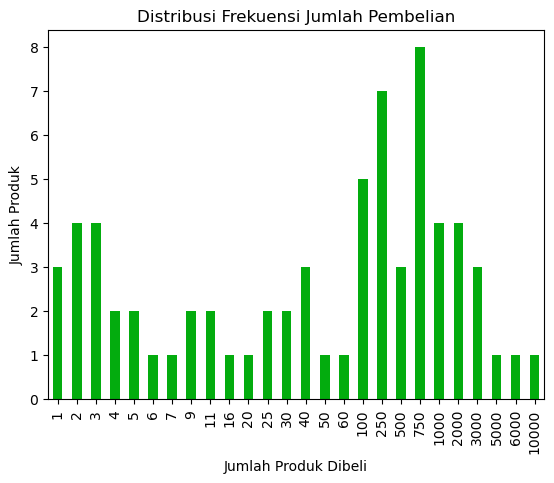

In [150]:
import matplotlib.pyplot as plt

# Tambahkan .sort_index() di akhir
counts = tokped['jumlah'].value_counts().sort_index()

counts.plot(kind='bar', color='#03ac0e')

plt.xlabel('Jumlah Produk Dibeli')
plt.ylabel('Jumlah Produk')
plt.title('Distribusi Frekuensi Jumlah Pembelian')
plt.show()

In [152]:
shopee = pd.read_csv('shopee_clean.csv')
shopee

,nama produk,harga,jumlah,kategori
0,Lampu Tumblr Kawat Mini 1-5M LED Diskon,2298,10000,Lampu
1,Gogolampu LED Hias Tumbler Bunga Balon,2281,10000,Lampu
2,Lampu LED 3 Mata 12V Roshan 6011,1470,10000,Lampu
3,Lampu LED Neon Flex 220V Waterproof 1M-100M,5800,10000,Lampu
4,GOGOLAND E005 Lampu Lilin elektrik LED,1879,10000,Lampu
5,ANG SARUNG JARI / SARUNG JEMPOL GAME,2600,10000,Sarung Jari
6,Lampu Hias LED 1M 10 LED Indoor Outdoor,2176,10000,Lampu
7,BG Lampu Tumblr Mini 1-5M LED 3 Mode,2274,10000,Lampu
8,"Kapasitor Kipas Angin CBB61 1.2UF, 1.5UF",2750,10000,Kapasitor Kipas Angin
9,Klem LED Strip Transparan / Klem Lampu,900,10000,Lampu


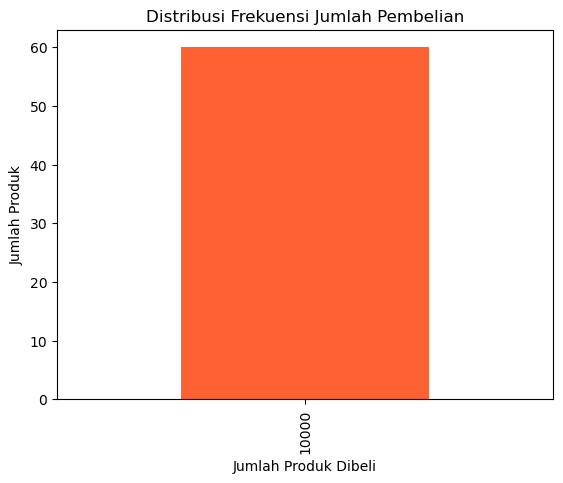

In [154]:
import matplotlib.pyplot as plt

# Tambahkan .sort_index() di akhir
counts = shopee['jumlah'].value_counts().sort_index()

counts.plot(kind='bar', color='#fe6232')

plt.xlabel('Jumlah Produk Dibeli')
plt.ylabel('Jumlah Produk')
plt.title('Distribusi Frekuensi Jumlah Pembelian')
plt.show()

## Kategori

In [157]:
tokped['kategori'].value_counts()

kategori
AC             10
TV             10
Mesin Cuci      9
Oven            8
Kulkas          8
Vacuum          7
Setrika         7
Rice Cooker     7
Knob            1
Blender         1
Baterai HT      1
Name: count, dtype: int64

In [159]:
shopee['kategori'].value_counts()

kategori
Lampu                    34
Stop Kontak              10
Sarung Jari               4
PCB                       4
Audio                     3
Baterai                   2
Kapasitor Kipas Angin     1
Kabel                     1
Baling-baling Kipas       1
Name: count, dtype: int64

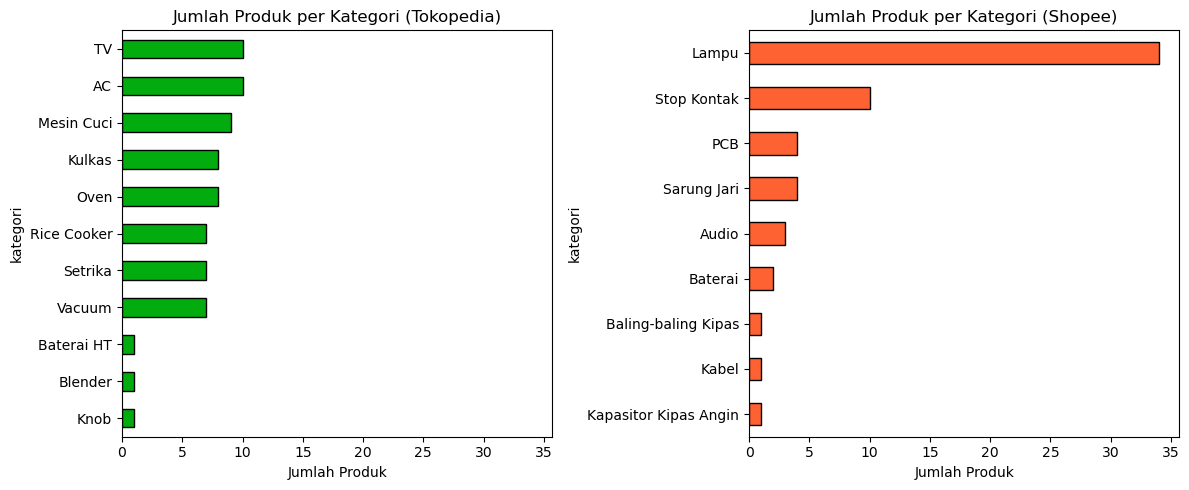

In [161]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

# Data
tokped_cat = tokped['kategori'].value_counts().sort_values(ascending=True)
shopee_cat = shopee['kategori'].value_counts().sort_values(ascending=True)

# Plot Tokopedia
tokped_cat.plot(kind='barh', ax=axes[0], color='#03ac0e', edgecolor='black')
axes[0].set_title('Jumlah Produk per Kategori (Tokopedia)')
axes[0].set_xlabel('Jumlah Produk')

# Plot Shopee
shopee_cat.plot(kind='barh', ax=axes[1], color='#fe6232', edgecolor='black')
axes[1].set_title('Jumlah Produk per Kategori (Shopee)')
axes[1].set_xlabel('Jumlah Produk')

plt.tight_layout()
plt.show()

### Jumlah pembelian

In [164]:
#tokopedia lebih tinggi secara sales sedangkan tokopedia secara pembelian. Target utama tokopedia sales in term of number, shopee berapa banyak pembelian in term of sales count

In [174]:
tokped['estimasi_sales'] = tokped['harga'] * tokped['jumlah']
print(f"total sales: Rp {tokped['estimasi_sales'].sum():,.0f}")
print(f"rata-rata sales: Rp {tokped['estimasi_sales'].mean():,.0f}")
print(f"nilai tengah sales: Rp {tokped['estimasi_sales'].median():,.0f}")
print(f"standard deviasi: Rp {tokped['estimasi_sales'].std():,.0f}")
print(f"skewness: {tokped['estimasi_sales'].skew()}")

total sales: Rp 108,904,796,888
rata-rata sales: Rp 1,578,330,390
nilai tengah sales: Rp 184,793,000
standard deviasi: Rp 5,870,378,021
skewness: 7.511321719258043


In [178]:
# Contoh formatting ke Rupiah tanpa desimal
shopee['estimasi_sales'] = shopee['harga'] * shopee['jumlah']
print(f"total sales: Rp {shopee['estimasi_sales'].sum():,.0f}")
print(f"rata-rata sales: Rp {shopee['estimasi_sales'].mean():,.0f}")
print(f"nilai tengah sales: Rp {shopee['estimasi_sales'].median():,.0f}")
print(f"standard deviasi: Rp {shopee['estimasi_sales'].std():,.0f}")
print(f"skewness: {shopee['estimasi_sales'].skew()}")

total sales: Rp 4,562,070,000
rata-rata sales: Rp 76,034,500
nilai tengah sales: Rp 25,000,000
standard deviasi: Rp 142,461,674
skewness: 4.819076651573047


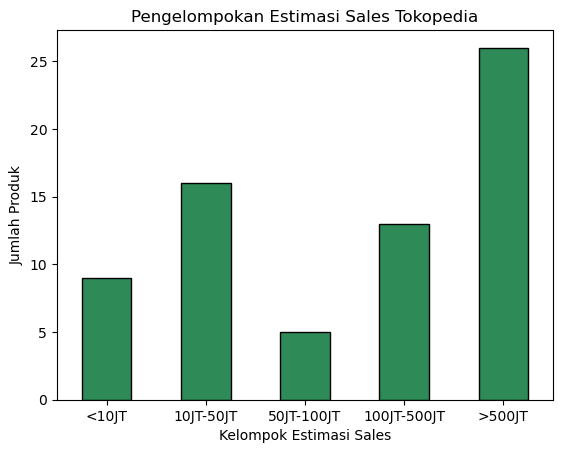

In [192]:
import pandas as pd
import matplotlib.pyplot as plt

# Tentukan batas interval angka (dalam rupiah)
bins = [0, 10_000_000, 50_000_000, 100_000_000, 500_000_000, float('inf')]
labels = ['<10JT', '10JT-50JT', '50JT-100JT', '100JT-500JT', '>500JT']

# Buat kolom kelompok baru
tokped['kategori_sales'] = pd.cut(tokped['estimasi_sales'], bins=bins, labels=labels)

# Plot frekuensi tiap kategori
tokped['kategori_sales'].value_counts().sort_index().plot(kind='bar', color='seagreen', edgecolor='black')

plt.xlabel('Kelompok Estimasi Sales')
plt.ylabel('Jumlah Produk')
plt.title('Pengelompokan Estimasi Sales Tokopedia')
plt.xticks(rotation=0)
plt.show()

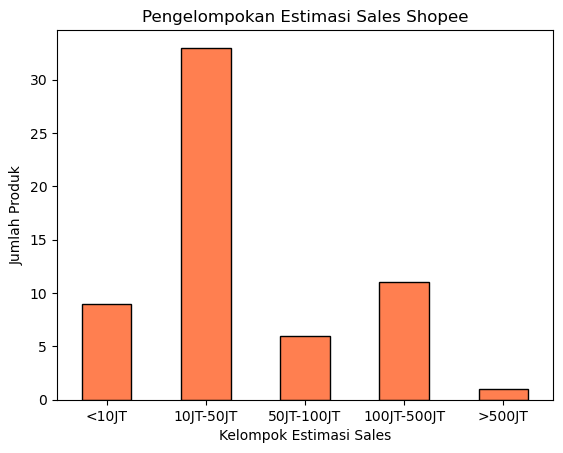

In [194]:
import pandas as pd
import matplotlib.pyplot as plt

# Pakai interval yang persis sama dengan Tokopedia
bins = [0, 10_000_000, 50_000_000, 100_000_000, 500_000_000, float('inf')]
labels = ['<10JT', '10JT-50JT', '50JT-100JT', '100JT-500JT', '>500JT']

shopee['kategori_sales'] = pd.cut(shopee['estimasi_sales'], bins=bins, labels=labels)

shopee['kategori_sales'].value_counts().sort_index().plot(kind='bar', color='coral', edgecolor='black')

plt.xlabel('Kelompok Estimasi Sales')
plt.ylabel('Jumlah Produk')
plt.title('Pengelompokan Estimasi Sales Shopee')
plt.xticks(rotation=0)
plt.show()

In [200]:
tokped_less_10m = tokped[tokped['estimasi_sales'] < 10_000_000]
tokped_less_10m

,nama produk,harga,jumlah,kategori,estimasi_sales,kategori_sales
39,Knob Channel HT Yaesu VX6,96000,2,Knob,192000,<10JT
46,MURAH..!!! MURAH..!!! BRACKET LED TV SEMUA MER...,100000,9,TV,900000,<10JT
49,Baterai HT BAOFENG UV-82 - Baofeng Indonesia,150000,20,Baterai HT,3000000,<10JT
51,Bracket Bravia LCD LED TV Monitor Ukuran 40-85...,100000,40,TV,4000000,<10JT
54,AQUA KULKAS 2 PINTU I AQR-D270 I aqrd270ls I a...,3190000,3,Kulkas,9570000,<10JT
55,"SHARP SJ-N162D-SH/SB/SP KULKAS 1 PINTU (BIRU,H...",2135000,3,Kulkas,6405000,<10JT
60,Ionizer Wire Honeywell Electronic Air Cleaner EAC,55000,25,AC,1375000,<10JT
64,Google TV 50 Inch Hisense U6K 50 ULED TV Quant...,7490000,1,TV,7490000,<10JT
65,LG Freezer GN-INV304BK ( Black ) / FREEZER LG ...,4199388,1,Kulkas,4199388,<10JT


In [202]:
shopee_less_10m = shopee[shopee['estimasi_sales'] < 10_000_000]
shopee_less_10m

,nama produk,harga,jumlah,kategori,estimasi_sales,kategori_sales
9,Klem LED Strip Transparan / Klem Lampu,900,10000,Lampu,9000000,<10JT
32,Cetak PCB bijian / partai,300,10000,PCB,3000000,<10JT
36,KLEM LAMPU NEON BRAKET LED NEON FLEX,750,10000,Lampu,7500000,<10JT
41,COSY Konektor Kabel Listrik Quick Connect,417,10000,Stop Kontak,4170000,<10JT
43,Original XRB 2PCS Sarung Jari Jempol,920,10000,Sarung Jari,9200000,<10JT
50,Dudukan Lampu Neon Flex LED 220V/12V 1Pcs,900,10000,Lampu,9000000,<10JT
57,Saklar Mini Merah/Hitam 15x10mm Saklar,575,10000,Stop Kontak,5750000,<10JT
58,Saklar Besar Merah/Hitam 21*15mm Saklar,559,10000,Stop Kontak,5590000,<10JT


### Sales base on kategori

In [204]:
# Tokopedia
tokped_sales_by_cat = tokped.groupby('kategori')['estimasi_sales'].sum().reset_index()

# Urutkan dari total sales terbesar
tokped_sales_by_cat = tokped_sales_by_cat.sort_values(by='estimasi_sales', ascending=False)

print(tokped_sales_by_cat)

       kategori  estimasi_sales
10       Vacuum     59287000000
5    Mesin Cuci     17399924000
0            AC     16013772000
8       Setrika      5680117500
6          Oven      5442268000
7   Rice Cooker      3886061000
9            TV       632560000
4        Kulkas       538463388
2       Blender        21439000
1    Baterai HT         3000000
3          Knob          192000


In [206]:
# Groupby dengan agregasi lengkap
cat_summary = tokped.groupby('kategori').agg(
    total_sales=('estimasi_sales', 'sum'),
    mean_sales=('estimasi_sales', 'mean'),
    jumlah_produk=('estimasi_sales', 'count')
).reset_index()

# Urutkan berdasarkan total sales terbanyak
cat_summary = cat_summary.sort_values(by='total_sales', ascending=False)

cat_summary['total_sales_formatted'] = cat_summary['total_sales'].apply(lambda x: f"Rp {x:,.0f}")
cat_summary['mean_sales_formatted'] = cat_summary['mean_sales'].apply(lambda x: f"Rp {x:,.0f}")

print(cat_summary[['kategori', 'total_sales_formatted', 'mean_sales_formatted', 'jumlah_produk']])

       kategori total_sales_formatted mean_sales_formatted  jumlah_produk
10       Vacuum     Rp 59,287,000,000     Rp 8,469,571,429              7
5    Mesin Cuci     Rp 17,399,924,000     Rp 1,933,324,889              9
0            AC     Rp 16,013,772,000     Rp 1,601,377,200             10
8       Setrika      Rp 5,680,117,500       Rp 811,445,357              7
6          Oven      Rp 5,442,268,000       Rp 680,283,500              8
7   Rice Cooker      Rp 3,886,061,000       Rp 555,151,571              7
9            TV        Rp 632,560,000        Rp 63,256,000             10
4        Kulkas        Rp 538,463,388        Rp 67,307,924              8
2       Blender         Rp 21,439,000        Rp 21,439,000              1
1    Baterai HT          Rp 3,000,000         Rp 3,000,000              1
3          Knob            Rp 192,000           Rp 192,000              1


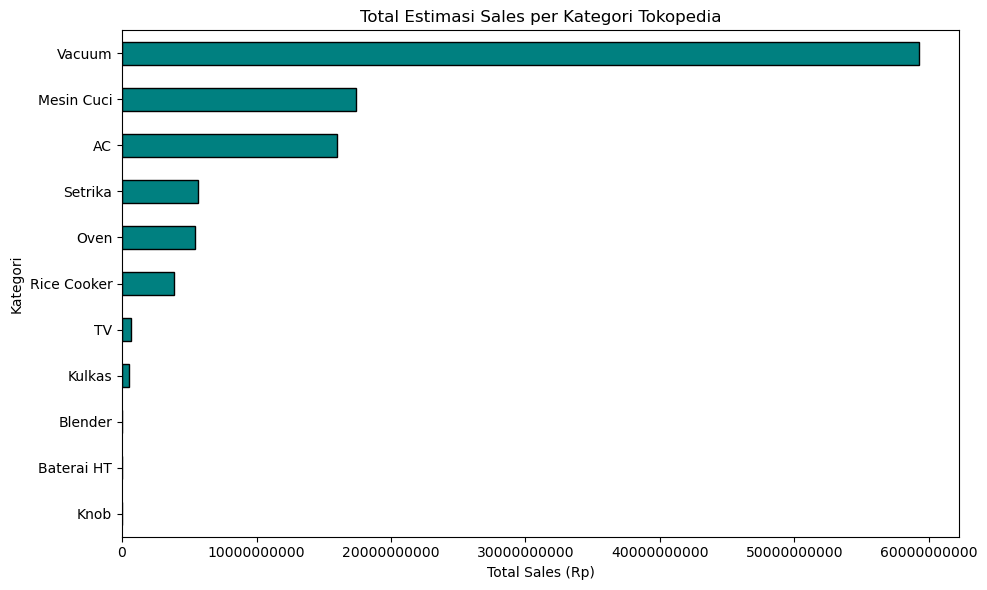

In [208]:
import matplotlib.pyplot as plt

# Hitung total sales per kategori
sales_per_cat = tokped.groupby('kategori')['estimasi_sales'].sum().sort_values(ascending=True)

# Plot horizontal bar
plt.figure(figsize=(10, 6))
sales_per_cat.plot(kind='barh', color='teal', edgecolor='black')

plt.title('Total Estimasi Sales per Kategori Tokopedia')
plt.xlabel('Total Sales (Rp)')
plt.ylabel('Kategori')
plt.ticklabel_format(style='plain', axis='x')  # Hilangkan scientific notation (1e9)
plt.tight_layout()
plt.show()

In [211]:
# Tokopedia
shopee_sales_by_cat = shopee.groupby('kategori')['estimasi_sales'].sum().reset_index()

# Urutkan dari total sales terbesar
shopee_sales_by_cat = shopee_sales_by_cat.sort_values(by='estimasi_sales', ascending=False)

print(shopee_sales_by_cat)

                kategori  estimasi_sales
5                  Lampu      3308080000
8            Stop Kontak       608560000
6                    PCB       275000000
2                Baterai       123990000
0                  Audio       102000000
7            Sarung Jari        75700000
4  Kapasitor Kipas Angin        27500000
1    Baling-baling Kipas        25000000
3                  Kabel        16240000


In [213]:
# Groupby dengan agregasi lengkap
scat_summary = shopee.groupby('kategori').agg(
    total_sales=('estimasi_sales', 'sum'),
    mean_sales=('estimasi_sales', 'mean'),
    jumlah_produk=('estimasi_sales', 'count')
).reset_index()

# Urutkan berdasarkan total sales terbanyak
scat_summary = scat_summary.sort_values(by='total_sales', ascending=False)

scat_summary['total_sales_formatted'] = scat_summary['total_sales'].apply(lambda x: f"Rp {x:,.0f}")
scat_summary['mean_sales_formatted'] = scat_summary['mean_sales'].apply(lambda x: f"Rp {x:,.0f}")

print(scat_summary[['kategori', 'total_sales_formatted', 'mean_sales_formatted', 'jumlah_produk']])

                kategori total_sales_formatted mean_sales_formatted  \
5                  Lampu      Rp 3,308,080,000        Rp 97,296,471   
8            Stop Kontak        Rp 608,560,000        Rp 60,856,000   
6                    PCB        Rp 275,000,000        Rp 68,750,000   
2                Baterai        Rp 123,990,000        Rp 61,995,000   
0                  Audio        Rp 102,000,000        Rp 34,000,000   
7            Sarung Jari         Rp 75,700,000        Rp 18,925,000   
4  Kapasitor Kipas Angin         Rp 27,500,000        Rp 27,500,000   
1    Baling-baling Kipas         Rp 25,000,000        Rp 25,000,000   
3                  Kabel         Rp 16,240,000        Rp 16,240,000   

   jumlah_produk  
5             34  
8             10  
6              4  
2              2  
0              3  
7              4  
4              1  
1              1  
3              1  


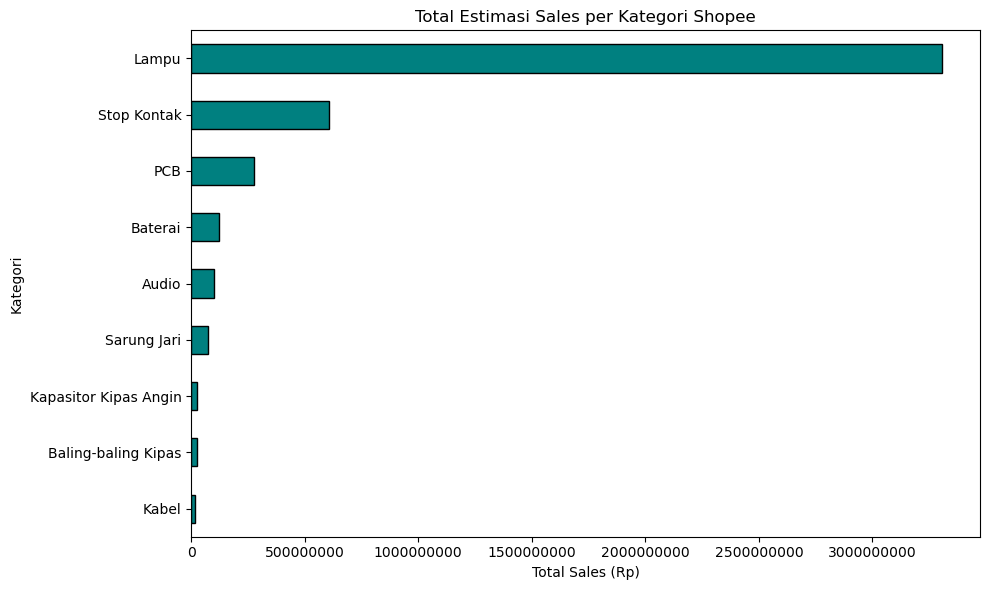

In [217]:
import matplotlib.pyplot as plt

# Hitung total sales per kategori
sales_per_cat = shopee.groupby('kategori')['estimasi_sales'].sum().sort_values(ascending=True)

# Plot horizontal bar
plt.figure(figsize=(10, 6))
sales_per_cat.plot(kind='barh', color='teal', edgecolor='black')

plt.title('Total Estimasi Sales per Kategori Shopee')
plt.xlabel('Total Sales (Rp)')
plt.ylabel('Kategori')
plt.ticklabel_format(style='plain', axis='x')  # Hilangkan scientific notation (1e9)
plt.tight_layout()
plt.show()